Certification Project – Used Cars Price Prediction

Domain –Price Prediction

First 5 rows of the dataset:
   Id  year          brand                                    full_model_name  \
0   0  2016          Honda                                    Honda Brio S MT   
1   1  2012         Nissan                             Nissan Sunny XV Diesel   
2   2  2017         Toyota             Toyota Fortuner 2.8 4x2 MT [2016-2020]   
3   3  2017  Mercedes-Benz  Mercedes-Benz E-Class E 220d Expression [2019-...   
4   4  2012        Hyundai                  Hyundai Verna Fluidic 1.6 CRDi SX   

  model_name      price  distance_travelled(kms) fuel_type    city  \
0       Brio   425000.0                   9680.0    Petrol  Mumbai   
1      Sunny   325000.0                 119120.0    Diesel  Mumbai   
2   Fortuner  2650000.0                  64593.0    Diesel   Thane   
3    E-Class  4195000.0                  25000.0    Diesel  Mumbai   
4      Verna   475000.0                  23800.0    Diesel  Mumbai   

   brand_rank  car_age  
0           7      5.0  
1          11

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera


Unique values and counts for categorical features:

Column: brand
brand
Hyundai             297
Maruti Suzuki       275
Honda               153
Mercedes-Benz       131
Toyota              117
BMW                 111
Audi                 98
Mahindra             93
Ford                 78
Volkswagen           70
Renault              51
Skoda                45
Tata                 44
Jaguar               30
Land Rover           28
Volvo                17
Nissan               13
Kia                  12
MG                   10
MINI                 10
Jeep                 10
Chevrolet             9
Porsche               5
Mitsubishi            4
Bentley               3
Datsun                3
Lexus                 2
Lamborghini           2
Fiat                  2
Isuzu                 1
Mahindra-Renault      1
Name: count, dtype: int64

Column: full_model_name
full_model_name
Ford EcoSport Titanium 1.5L TDCi                 12
Toyota Innova Crysta 2.4 VX 8 STR [2016-2020]    11
Audi Q7 3.0 

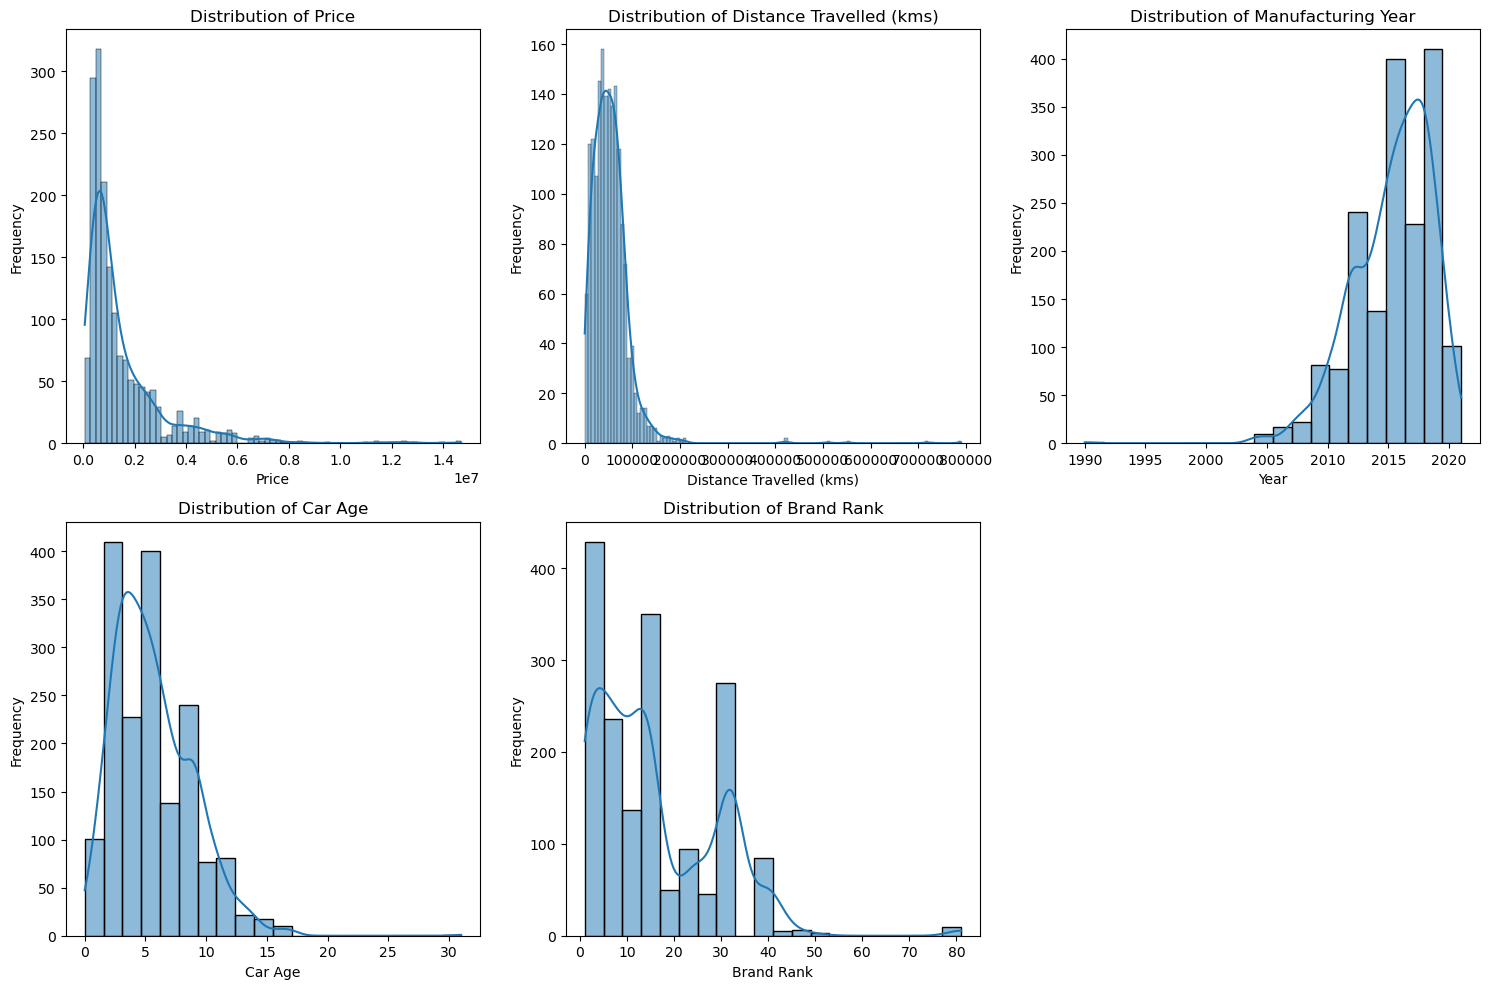

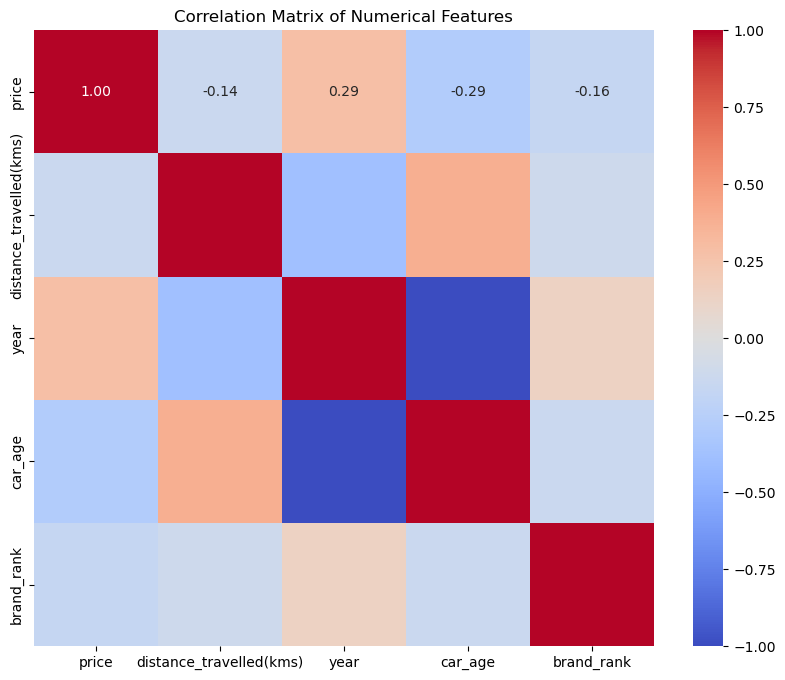

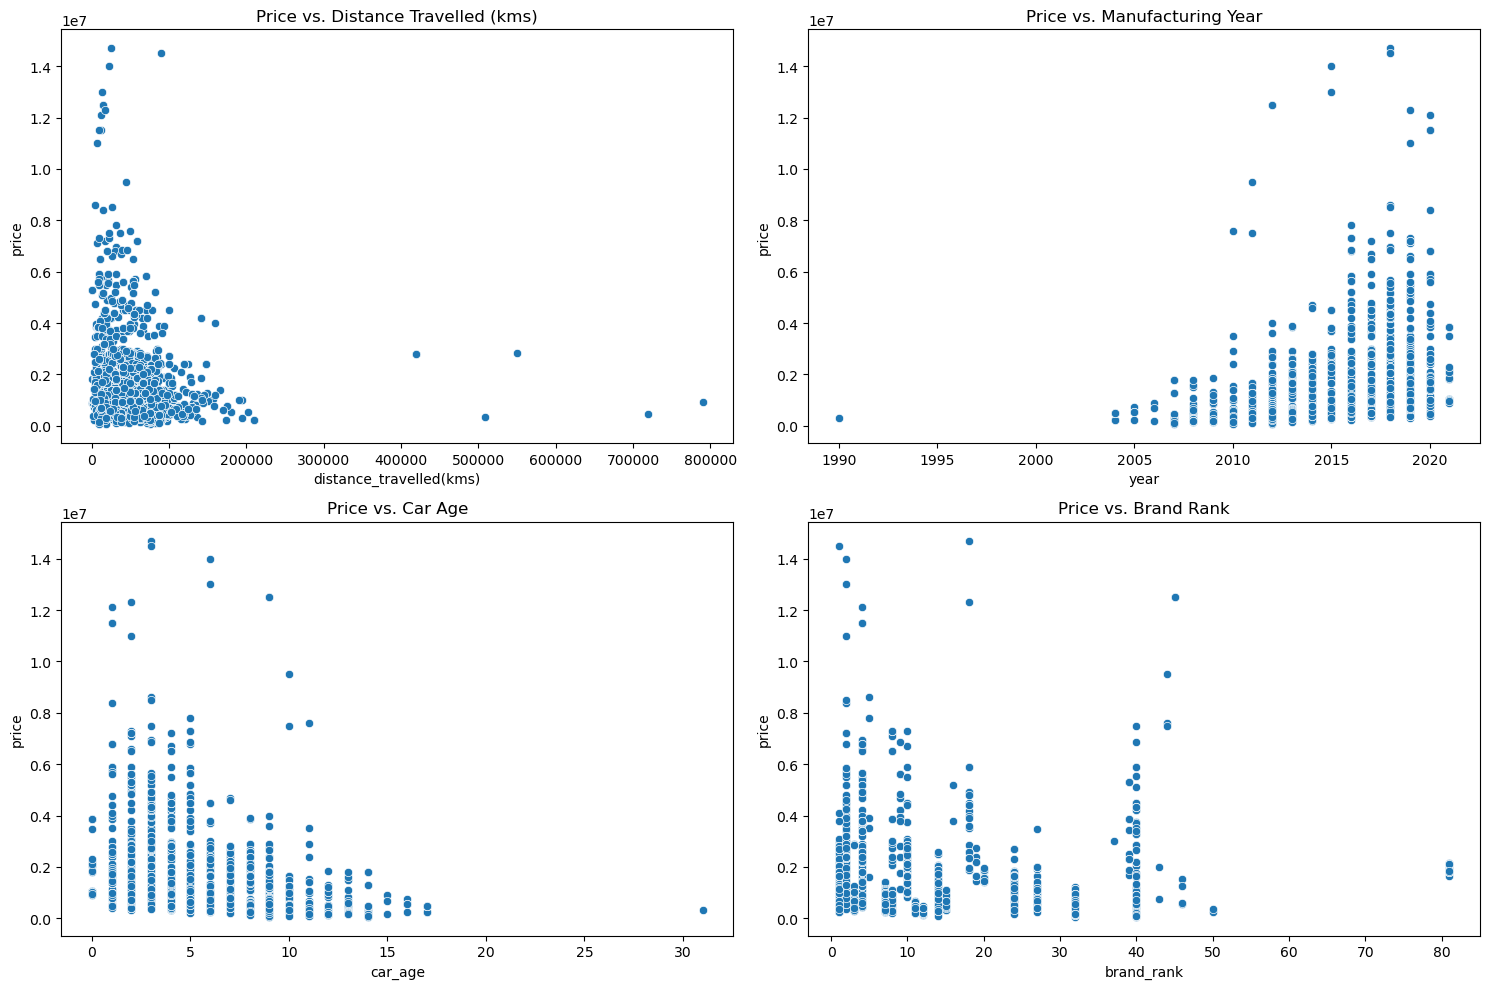

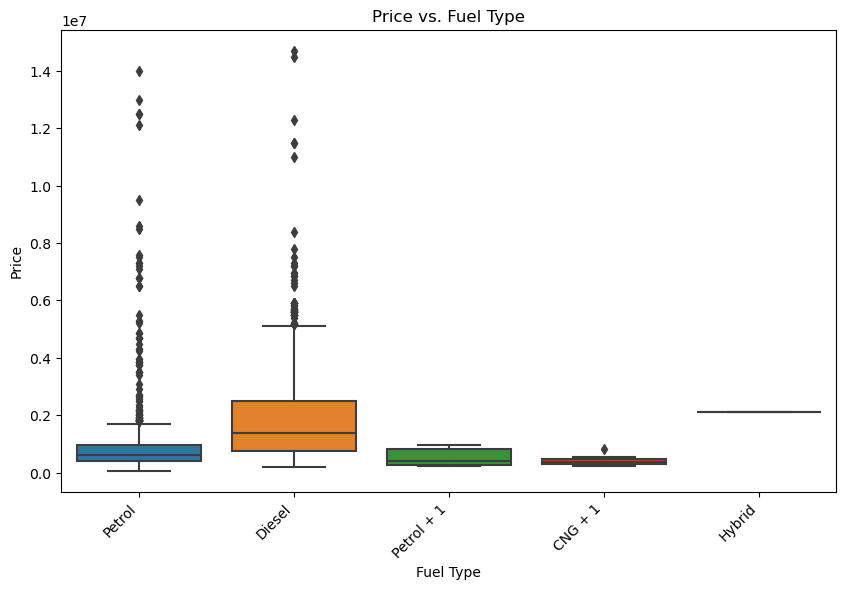

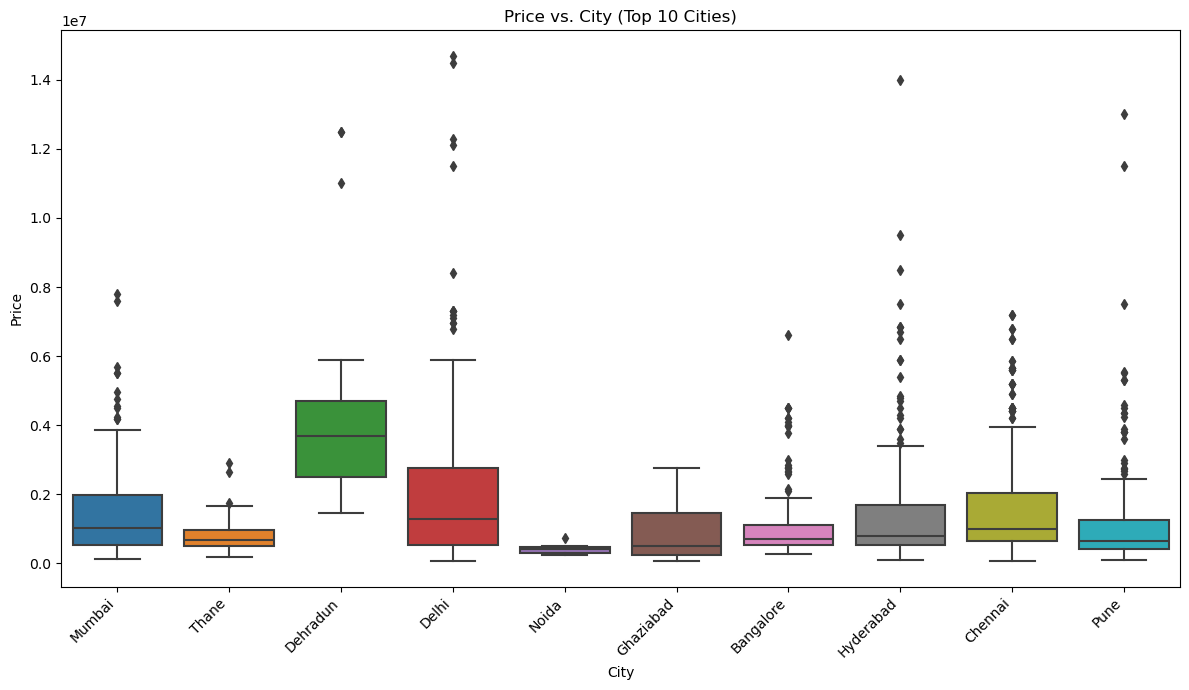

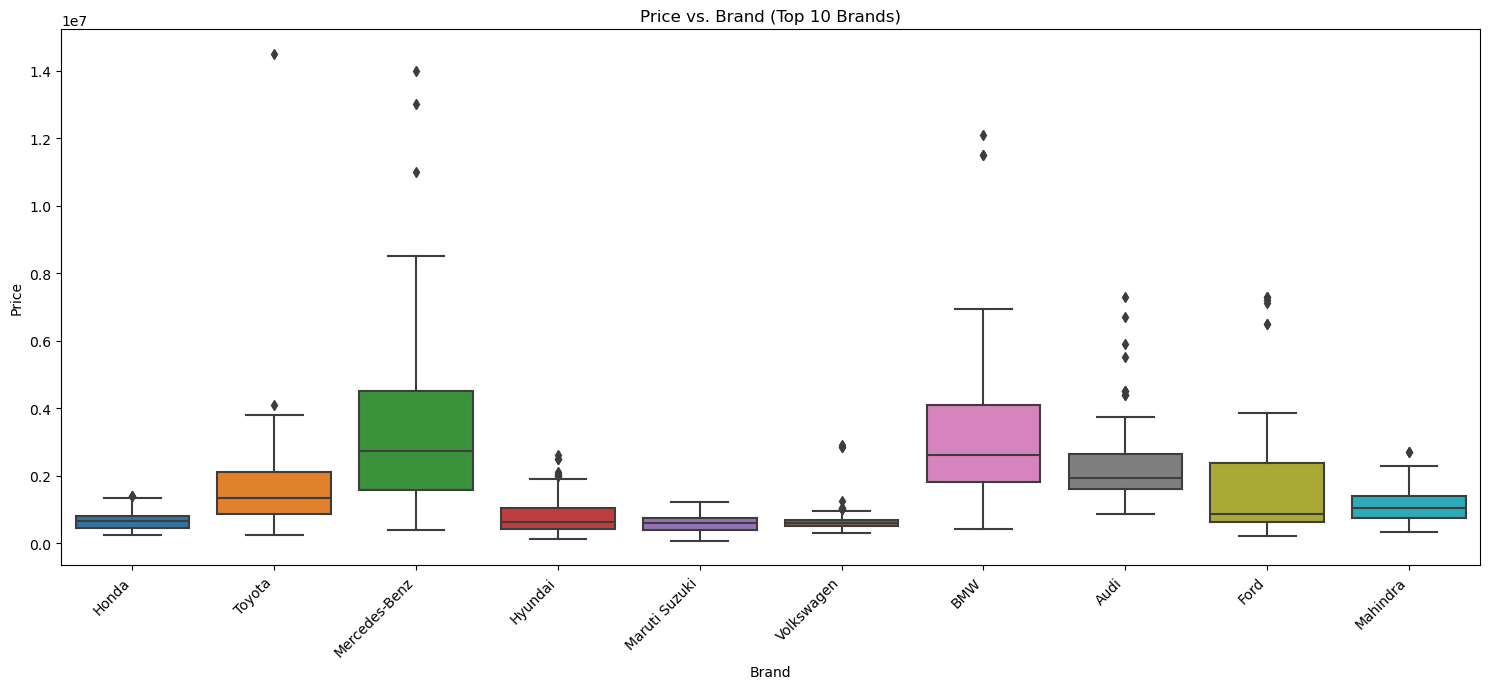

--- Linear Regression ---
R2 Score: 0.6940
MAE: 449933.55
RMSE: 1013514.68
-------------------------
--- Decision Tree Regressor ---
R2 Score: 0.7000
MAE: 290400.97
RMSE: 1003579.40
-------------------------------
--- Random Forest Regressor ---
R2 Score: 0.7250
MAE: 313846.86
RMSE: 960866.05
-------------------------------
--- Gradient Boosting Regressor ---
R2 Score: 0.6729
MAE: 474194.27
RMSE: 1047904.71
-----------------------------------

Model Performance Comparison:
                             R2 Score            MAE          RMSE
Linear Regression            0.694010  449933.545890  1.013515e+06
Decision Tree Regressor      0.699980  290400.966184  1.003579e+06
Random Forest Regressor      0.724975  313846.856453  9.608661e+05
Gradient Boosting Regressor  0.672893  474194.270126  1.047905e+06

Best performing model based on R2 Score: Random Forest Regressor with R2 Score of 0.7250

Most important features for the best model (Tree-based):
car_age                    0.161054
bra

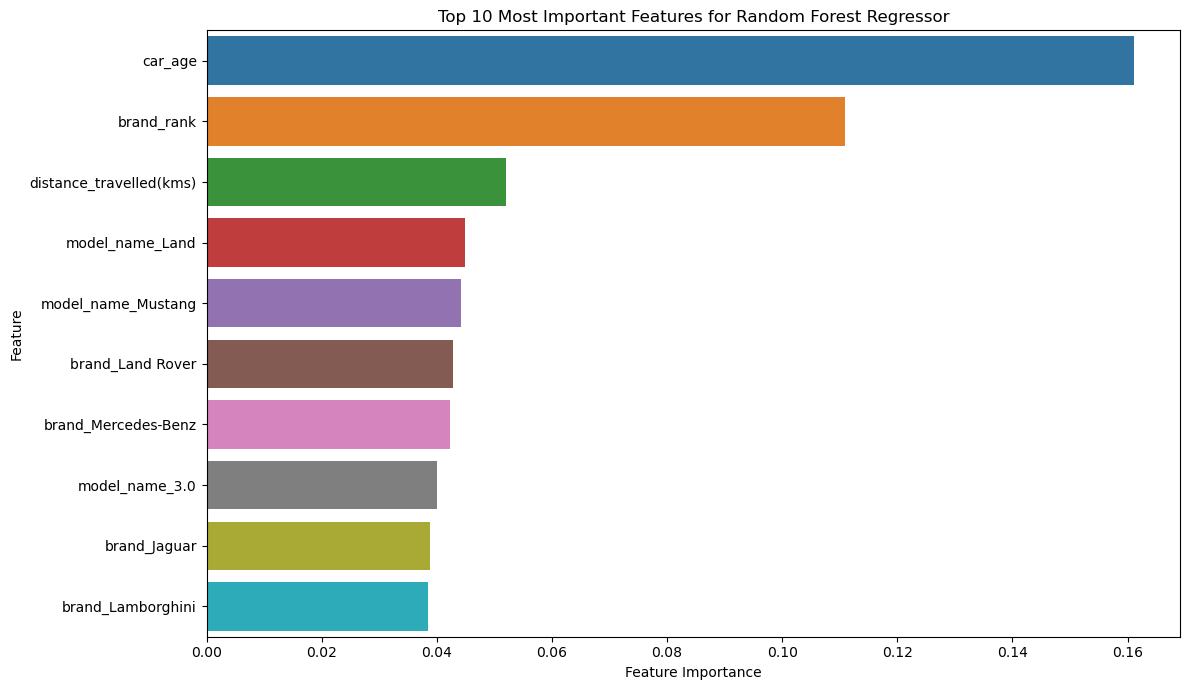

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('cars.csv')

print("First 5 rows of the dataset:")
print(df.head())
print("\nInformation about the dataset:")
print(df.info())
print("\nDescriptive statistics for numerical columns:")
print(df.describe())

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
sns.histplot(df['distance_travelled(kms)'], kde=True)
plt.title('Distribution of Distance Travelled (kms)')
plt.xlabel('Distance Travelled (kms)')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
sns.histplot(df['year'], kde=True, bins=20)
plt.title('Distribution of Manufacturing Year')
plt.xlabel('Year')
plt.ylabel('Frequency')

plt.subplot(2, 3, 4)
sns.histplot(df['car_age'], kde=True, bins=20)
plt.title('Distribution of Car Age')
plt.xlabel('Car Age')
plt.ylabel('Frequency')

plt.subplot(2, 3, 5)
sns.histplot(df['brand_rank'], kde=True, bins=20)
plt.title('Distribution of Brand Rank')
plt.xlabel('Brand Rank')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('numerical_features_histograms.png')

print("\nUnique values and counts for categorical features:")

categorical_cols = ['brand', 'full_model_name', 'model_name', 'fuel_type', 'city']

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

numerical_cols = ['price', 'distance_travelled(kms)', 'year', 'car_age', 'brand_rank']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('correlation_matrix.png')
plt.show()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.scatterplot(x='distance_travelled(kms)', y='price', data=df)
plt.title('Price vs. Distance Travelled (kms)')

plt.subplot(2, 2, 2)
sns.scatterplot(x='year', y='price', data=df)
plt.title('Price vs. Manufacturing Year')

plt.subplot(2, 2, 3)
sns.scatterplot(x='car_age', y='price', data=df)
plt.title('Price vs. Car Age')

plt.subplot(2, 2, 4)
sns.scatterplot(x='brand_rank', y='price', data=df)
plt.title('Price vs. Brand Rank')

plt.tight_layout()
plt.savefig('numerical_features_vs_price_scatterplots.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='price', data=df)
plt.title('Price vs. Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.savefig('price_vs_fuel_type_boxplot.png')
plt.show()

plt.figure(figsize=(12, 7))
top_10_cities = df['city'].value_counts().nlargest(10).index
sns.boxplot(x='city', y='price', data=df[df['city'].isin(top_10_cities)])
plt.title('Price vs. City (Top 10 Cities)')
plt.xlabel('City')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('price_vs_city_boxplot.png')
plt.show()

plt.figure(figsize=(15, 7))
top_10_brands = df['brand'].value_counts().nlargest(10).index
sns.boxplot(x='brand', y='price', data=df[df['brand'].isin(top_10_brands)])
plt.title('Price vs. Brand (Top 10 Brands)')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('price_vs_brand_boxplot.png')
plt.show()

#Step 3 & 4 & 5
df_processed = df.drop(columns=['Id', 'year', 'full_model_name'])
X = df_processed.drop('price', axis=1)
y = df_processed['price']

numerical_features = ['distance_travelled(kms)', 'car_age', 'brand_rank']
categorical_features = ['brand', 'model_name', 'fuel_type', 'city']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

results = {}
best_model_pipeline = None

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {'R2 Score': r2, 'MAE': mae, 'RMSE': rmse}

    print(f"--- {name} ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-" * (len(name) + 8))
    
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)

best_model_name = results_df['R2 Score'].idxmax()
best_model_r2 = results_df['R2 Score'].max()

print(f"\nBest performing model based on R2 Score: {best_model_name} with R2 Score of {best_model_r2:.4f}")

best_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('regressor', models[best_model_name])])
best_model_pipeline.fit(X_train, y_train)

ohe_feature_names = best_model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(ohe_feature_names)

if best_model_name in ['Decision Tree Regressor', 'Random Forest Regressor', 'Gradient Boosting Regressor']:
    importances = best_model_pipeline.named_steps['regressor'].feature_importances_
    feature_importances = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)
    print("\nMost important features for the best model (Tree-based):")
    print(feature_importances.head(10))

    plt.figure(figsize=(12, 7))
    sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index)
    plt.title(f'Top 10 Most Important Features for {best_model_name}')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(f'{best_model_name}_feature_importances.png')
    plt.show()

elif best_model_name == 'Linear Regression':
    coefficients = best_model_pipeline.named_steps['regressor'].coef_
    feature_coefficients = pd.Series(coefficients, index=all_feature_names).abs().sort_values(ascending=False)
    print("\nMost important features for Linear Regression (Absolute Coefficients):")
    print(feature_coefficients.head(10))
    
    plt.figure(figsize=(12, 7))
    sns.barplot(x=feature_coefficients.head(10).values, y=feature_coefficients.head(10).index)
    plt.title(f'Top 10 Most Important Features for {best_model_name} (Absolute Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(f'{best_model_name}_feature_coefficients.png')
    plt.show()